# Participants Layers

In [7]:
# imports
import os
os.environ['KERAS_BACKEND'] = 'torch'
from typing import Literal

import numpy as np
import pandas as pd
import xarray as xr
from matplotlib import pyplot as plt
from keras.saving import load_model
from sklearn.metrics.pairwise import cosine_similarity

def load_subject_weights(model,
                         component: Literal['generator', 'critic']='generator'):
    if component == 'generator':
        subject_layer = model.generator.get_layer(model.generator.layers[0].name).module
    elif component == 'critic':
        subject_layer = model.critic.get_layer(model.critic.layers[0].name).module
    else:
        raise ValueError(f'{component} is not a valid model')
    return subject_layer.weights.detach().cpu().numpy()

## Visualize subject layer evolution over time

In [ ]:
checkpoint_dir = "logs/5/"
epochs = list(range(20, 500, 20))
weights_over_time_gen = []
weights_over_time_crt = []

for epoch in epochs:
    path = os.path.join(checkpoint_dir, f"20250605_7th_epoch_{epoch}.model.keras")
    model = load_model(path, compile=False)
    weights_gen = load_subject_weights(model)  # shape: (n_subjects, in_ch, out_ch)
    weights_crt = load_subject_weights(model, component='critic')
    weights_over_time_gen.append(weights_gen)
    weights_over_time_crt.append(weights_crt)

weights_over_time_gen = np.array(weights_over_time_gen)
weights_over_time_crt = np.array(weights_over_time_crt)

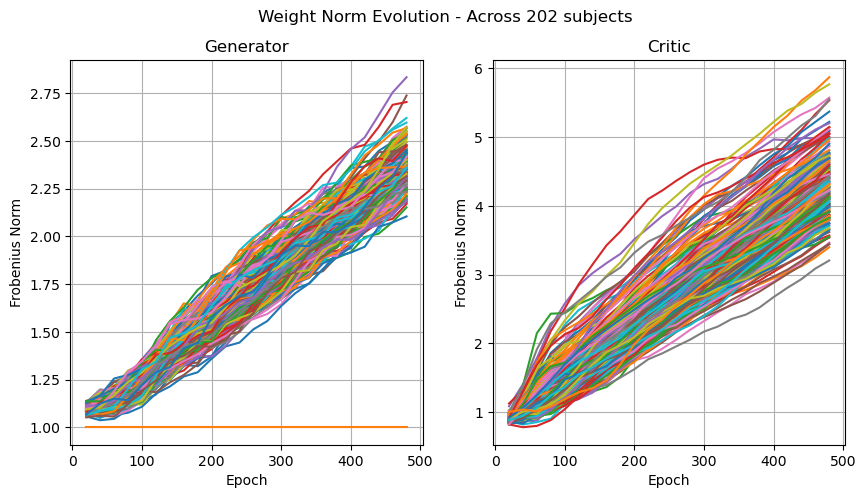

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

for subject_id in range(202):
    norms_gen = np.linalg.norm(weights_over_time_gen[:, subject_id], axis=(1, 2))
    norms_crt = np.linalg.norm(weights_over_time_crt[:, subject_id], axis=(1, 2))

    for i, (norms, name) in enumerate(zip([norms_gen, norms_crt], ['Generator', 'Critic'])):
        ax[i].plot(epochs, norms)
        ax[i].set_title(f"{name}")
        ax[i].set_xlabel("Epoch")
        ax[i].set_ylabel("Frobenius Norm")
        ax[i].grid(True)

fig.suptitle('Weight Norm Evolution - Across 202 subjects')
plt.show()

The constantly progressing weight norm shows that the subject layer is actively learning, with growing norms. also no subject is ignored (except for the last participant in the generator)

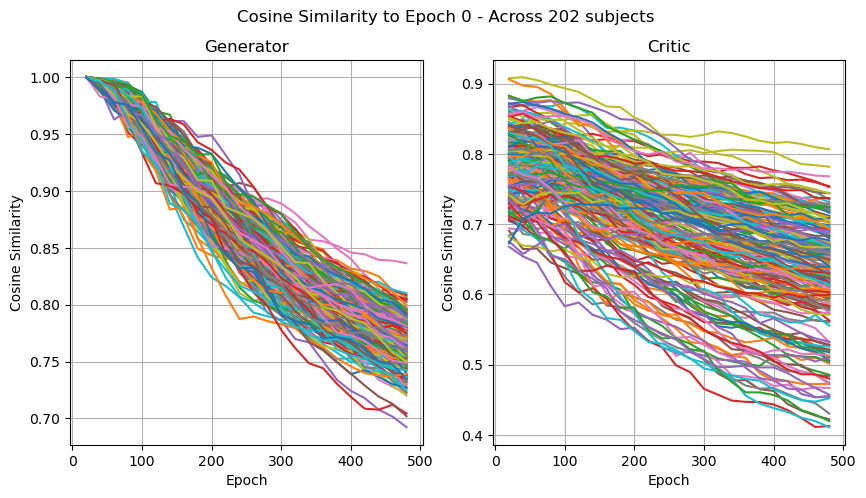

In [22]:
# divergance from the first epoch
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

for subject_id in range(201):
    w0_gen = weights_over_time_gen[0, subject_id].reshape(1, -1)
    w0_crt = weights_over_time_crt[0, subject_id].reshape(1, -1)

    cos_sims_gen = [cosine_similarity(w0_gen, w.reshape(1, -1))[0, 0] for w in weights_over_time_gen[:, subject_id]]
    cos_sims_crt = [cosine_similarity(w0_crt, w.reshape(1, -1))[0, 0] for w in weights_over_time_gen[:, subject_id]]

    for i, (cos_sims, name) in enumerate(zip([cos_sims_gen, cos_sims_crt], ['Generator', 'Critic'])):
        ax[i].plot(epochs, cos_sims)
        ax[i].set_title(f'{name}')
        ax[i].set_xlabel("Epoch")
        ax[i].set_ylabel("Cosine Similarity")
        ax[i].grid(True)
fig.suptitle('Cosine Similarity to Epoch 0 - Across 202 subjects')
plt.show()

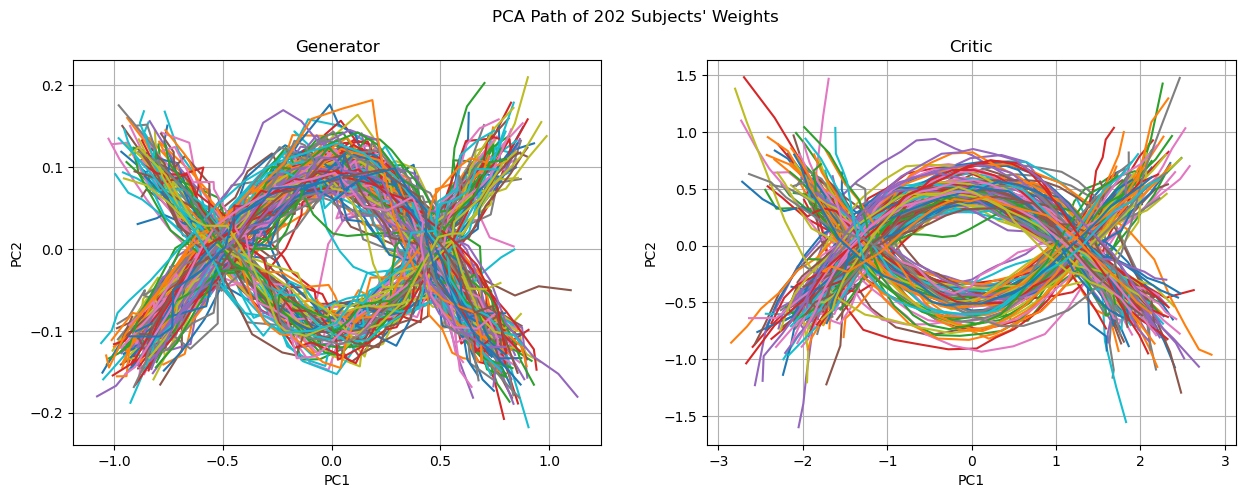

In [28]:
demographics = pd.read_csv('data/LEMON_DATA/Demographics.csv')
EEG = xr.open_dataarray('data/LEMON_DATA/EC_ch-8_sf-128.nc5', engine='h5netcdf')
sub_ids = list(EEG.subject.values)
demographics['age_group'] = demographics['Age'].apply(lambda x: 'young' if x=='20-25' or x=='25-30' else 'old')
gender = demographics.set_index('ID').loc[sub_ids, 'Gender_ 1=female_2=male'].values
from sklearn.decomposition import PCA
COLOR_CODE = False
ANNOT = False

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

for subject_id in range(202):
    subject_weights_gen = weights_over_time_gen[:, subject_id].reshape(len(epochs), -1)
    subject_weights_crt = weights_over_time_crt[:, subject_id].reshape(len(epochs), -1)

    for i, (coords, name) in enumerate(zip([subject_weights_gen, subject_weights_crt], ['Generator', 'Critic'])):
        pca = PCA(n_components=2)
        coords = pca.fit_transform(coords)

        if COLOR_CODE:
            if gender[subject_id] == 1:
                color = 'red'
            if gender[subject_id] == 0:
                color = 'blue'
            ax[i].plot(coords[:, 0], coords[:, 1], color=color)
        else:
            ax[i].plot(coords[:, 0], coords[:, 1])
        
        if ANNOT:
            for i, epoch in enumerate(epochs):
                ax[i].annotate(str(epoch), (coords[i, 0], coords[i, 1]), fontsize=8)
        
        ax[i].set_title(f"{name}")
        ax[i].set_xlabel("PC1")
        ax[i].set_ylabel("PC2")
        ax[i].grid(True)

fig.suptitle("PCA Path of 202 Subjects' Weights")
plt.show()


This interesting decomposed components hints that there's a latent structure — possibly two main subject groups or adaptation strategies.